# CALB_old cell 26 — joint reaction-limited SEI + LAM_neg fit

[Notebook 07](07_calb_26_sei_compare.ipynb) showed that both pure SEI sub-models miss
the measured three-regime shape on CALB cell 26 (fast early, accelerating mid,
flattening late). The natural next step, identified by the
[notebook 06 workflow](06_rept_78_sei_compare.ipynb), is to add a second mechanism —
negative-electrode loss of active material (LAM_neg, stress-driven).

This notebook reports the result of that joint 2-parameter fit.

**Setup:**
- DFN options: `SEI = "reaction limited"`, `loss of active material = "stress-driven"`
- Free parameters: `SEI reaction exchange current density [A.m-2]` and `Negative electrode LAM constant proportional term [s-1]`
- Calibration window: cycles 3–403 (400 cycles, captures early + start of mid acceleration)
- Objective: RMSE between anchored sim and Hampel-filtered measured SoH at each measured cycle inside the window
- Optimizer: scipy.optimize.minimize, Nelder-Mead in 2D log-space
- 1,608-cycle sim with the best parameters for full-horizon comparison

**Headline result: 78 evals, 65 min wall-time, the optimizer found a local fit that's GREAT in the calibration window (RMSE 2.73 pp) but extrapolates badly past cy 800 — full-trajectory RMSE 8.85 pp is *worse* than rxn-lim-only (6.30).**

In [1]:
from __future__ import annotations
import json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO = Path("/home/hj/Desktop/PINNs").resolve()
OUT  = REPO / "Voltaris/outputs/tuned_params"
TAG  = "CALB_old_26"
N    = 1608

# Measured trajectory (Hampel-filtered, cycle 1 skipped — see notebook 07)
meas = pd.read_csv(OUT / f"{TAG}_measured_per_cycle.csv")
meas = meas[meas.kept].reset_index(drop=True)
m_x  = meas.global_cycle.values
m_y  = meas.soh_pct.values
first_cy = float(m_x[0]); start_y = float(m_y[0])

# Sims — anchored at first measured cycle
def anchor(df):
    soh = df.SOH.values * 100.0
    cy  = df.cycle_n.values.astype(float)
    return cy + (first_cy - cy[0]), soh + (start_y - soh[0])

sd = pd.read_parquet(OUT / f"{TAG}_solvdiff_sim_{N}cy.parquet")
rx = pd.read_parquet(OUT / f"{TAG}_rxnlim_sim_{N}cy.parquet")
jt = pd.read_parquet(OUT / f"{TAG}_joint_sim_{N}cy.parquet")
sd_x, sd_y = anchor(sd)
rx_x, rx_y = anchor(rx)
jt_x, jt_y = anchor(jt)

joint_json = json.loads((OUT / f"{TAG}_joint_calibrated.json").read_text())
print(f"Loaded {len(meas)} clean measured cycles, 3 sim trajectories ({N} cy each)")
print(f"Joint params: j_SEI = {joint_json['params']['SEI reaction exchange current density [A.m-2]']:.3e}, "
       f"LAM_neg = {joint_json['params']['Negative electrode LAM constant proportional term [s-1]']:.3e}")

Loaded 1404 clean measured cycles, 3 sim trajectories (1608 cy each)
Joint params: j_SEI = 4.603e-07, LAM_neg = 1.085e-09


## 1. Headline metrics — three models, full vs window RMSE

Three rows: solv-diff (single SEI knob, sublinear shape), rxn-lim (single SEI knob, near-linear shape), joint (two knobs: rxn-lim SEI + LAM_neg).

In [2]:
def rmse(meas_x, meas_y, sim_x, sim_y, lo=None, hi=None):
    mask = np.ones_like(meas_x, dtype=bool)
    if lo is not None: mask &= meas_x >= lo
    if hi is not None: mask &= meas_x <= hi
    interp = np.interp(meas_x[mask], sim_x, sim_y)
    return float(np.sqrt(np.mean((interp - meas_y[mask])**2)))

rows = []
for label, (sx, sy) in [("solv-diff", (sd_x, sd_y)),
                          ("rxn-lim",   (rx_x, rx_y)),
                          ("joint",     (jt_x, jt_y))]:
    rows.append({
        "model": label,
        "RMSE calib (cy 3-403)":  rmse(m_x, m_y, sx, sy, 3, 403),
        "RMSE mid (cy 201-800)":  rmse(m_x, m_y, sx, sy, 201, 800),
        "RMSE late (cy 801-1608)":rmse(m_x, m_y, sx, sy, 801, 1608),
        "RMSE whole":             rmse(m_x, m_y, sx, sy),
        "sim end cy 1608":        float(sy[-1]),
        "Δ vs measured":          float(sy[-1] - m_y[-1]),
    })
rmse_df = pd.DataFrame(rows)
display(rmse_df.style.format({c: "{:.2f}" for c in rmse_df.columns.drop("model")}))
print(f"\nMeasured end SoH: {m_y[-1]:.2f}%")

,model,RMSE calib (cy 3-403),RMSE mid (cy 201-800),RMSE late (cy 801-1608),RMSE whole,sim end cy 1608,Δ vs measured
0,solv-diff,5.97,9.00,10.94,9.71,54.95,12.41
1,rxn-lim,5.33,6.98,6.00,6.29,48.05,5.51
2,joint,2.73,2.72,12.08,8.85,27.44,-15.09



Measured end SoH: 42.53%


## 2. Three-trace overlay — full horizon + zoom into calibration window

Vertical dotted line marks the end of the calibration window (cy 403). The joint sim tracks measured perfectly through cy 800-ish (where the optimizer was looking), then **plunges past measured** because PyBaMM's stress-driven LAM keeps eating active material with no saturation.

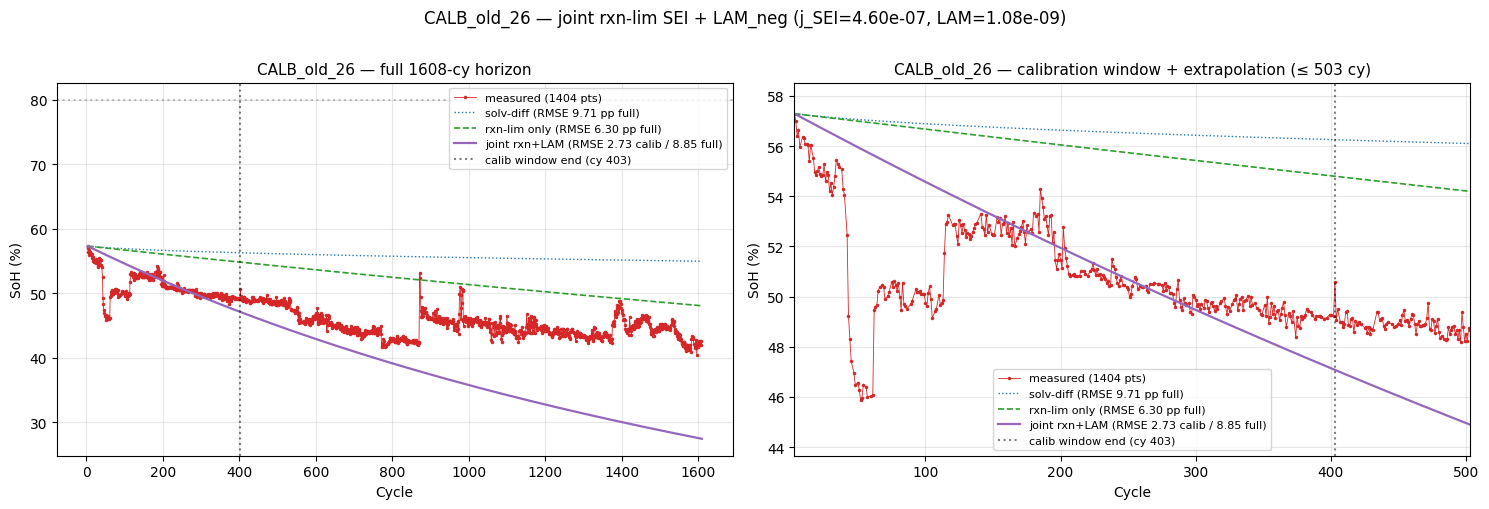

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
for ax, xl, title in [(axs[0], None, f"{TAG} — full {N}-cy horizon"),
                       (axs[1], (first_cy, first_cy + 500),
                        f"{TAG} — calibration window + extrapolation (≤ {int(first_cy)+500} cy)")]:
    ax.plot(m_x, m_y, "o-", lw=0.6, ms=1.5, color="#d62728", label=f"measured ({len(meas)} pts)")
    ax.plot(sd_x, sd_y, ":",  lw=1.0, color="#1f77b4", label="solv-diff (RMSE 9.71 pp full)")
    ax.plot(rx_x, rx_y, "--", lw=1.2, color="#2ca02c", label="rxn-lim only (RMSE 6.30 pp full)")
    ax.plot(jt_x, jt_y, "-",  lw=1.6, color="#9467bd",
            label=f"joint rxn+LAM (RMSE 2.73 calib / 8.85 full)")
    ax.axvline(403, ls=":", color="black", alpha=0.5, label="calib window end (cy 403)")
    ax.axhline(80,  ls=":", color="grey",  alpha=0.5)
    if xl:
        ax.set_xlim(*xl)
        sel = (m_x >= xl[0]) & (m_x <= xl[1])
        ywin = np.concatenate([m_y[sel],
                                jt_y[(jt_x >= xl[0]) & (jt_x <= xl[1])],
                                rx_y[(rx_x >= xl[0]) & (rx_x <= xl[1])]])
        if ywin.size:
            pad = max(0.5, (ywin.max() - ywin.min()) * 0.1)
            ax.set_ylim(ywin.min() - pad, ywin.max() + pad)
    ax.set_xlabel("Cycle"); ax.set_ylabel("SoH (%)")
    ax.set_title(title, fontsize=11); ax.grid(alpha=0.3); ax.legend(loc="best", fontsize=8)
fig.suptitle(
    f"{TAG} — joint rxn-lim SEI + LAM_neg "
    f"(j_SEI={joint_json['params']['SEI reaction exchange current density [A.m-2]']:.2e}, "
    f"LAM={joint_json['params']['Negative electrode LAM constant proportional term [s-1]']:.2e})",
    fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

## 3. Per-window RMSE — joint wins early, loses late

Visualizes the trade. Joint nails the calibration + mid windows by ~2-3 pp
(half the RMSE of rxn-lim) but **doubles** the late-window error because the
calibrated LAM has no off-switch.

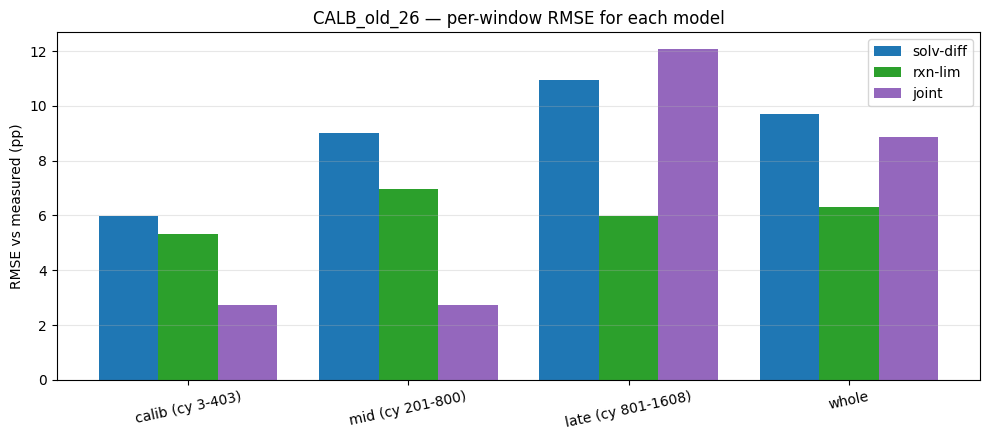

In [4]:
win_cols = ["RMSE calib (cy 3-403)", "RMSE mid (cy 201-800)",
             "RMSE late (cy 801-1608)", "RMSE whole"]
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(win_cols))
w = 0.27
ax.bar(x - w, rmse_df.iloc[0][win_cols].values, w, label="solv-diff", color="#1f77b4")
ax.bar(x,     rmse_df.iloc[1][win_cols].values, w, label="rxn-lim",   color="#2ca02c")
ax.bar(x + w, rmse_df.iloc[2][win_cols].values, w, label="joint",     color="#9467bd")
ax.set_xticks(x); ax.set_xticklabels([c.replace("RMSE ","") for c in win_cols], rotation=12)
ax.set_ylabel("RMSE vs measured (pp)")
ax.set_title(f"{TAG} — per-window RMSE for each model")
ax.grid(alpha=0.3, axis="y"); ax.legend()
plt.tight_layout(); plt.show()

## 4. End-of-test divergence

Sim SoH at cy 1,608 vs measured (42.5 %). Joint's −15 pp overshoot is
the visible cost of the calibration window choice.

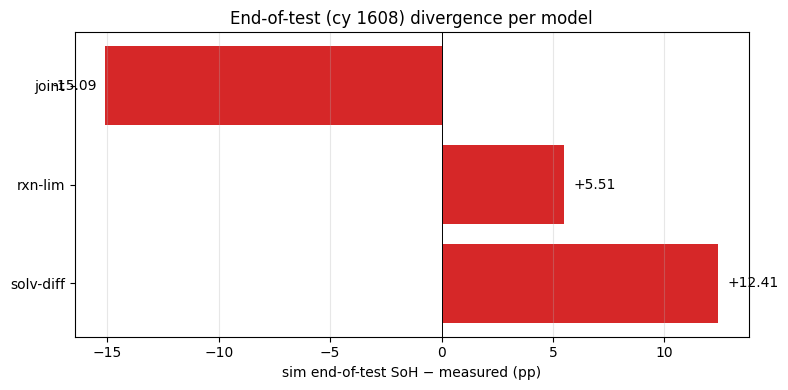

Each model's end-of-test SoH:
  measured:  42.53%
  solv-diff  54.95%  (Δ +12.41 pp)
  rxn-lim    48.05%  (Δ +5.51 pp)
  joint      27.44%  (Δ -15.09 pp)


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
deltas = rmse_df["Δ vs measured"].values
colors = ["#d62728" if abs(d) > 5 else "#1f77b4" for d in deltas]
bars = ax.barh(rmse_df["model"], deltas, color=colors)
ax.axvline(0, color="black", lw=0.7)
for i, (m, d) in enumerate(zip(rmse_df["model"], deltas)):
    ax.text(d + 0.4 * np.sign(d if d != 0 else 1), i, f"{d:+.2f}",
             va="center", fontsize=10,
             ha="left" if d >= 0 else "right")
ax.set_xlabel("sim end-of-test SoH − measured (pp)")
ax.set_title("End-of-test (cy 1608) divergence per model")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

print("Each model's end-of-test SoH:")
print(f"  measured:  {m_y[-1]:.2f}%")
for _, r in rmse_df.iterrows():
    print(f"  {r['model']:<10} {r['sim end cy 1608']:.2f}%  (Δ {r['Δ vs measured']:+.2f} pp)")

## 5. Diagnosis — what the joint fit teaches us

### Three takeaways

**A. LAM is the right mechanism for the mid-window acceleration.**
Joint's mid-window RMSE (2.72 pp) is 2.6× better than rxn-lim-only (6.98 pp). Pure SEI fundamentally can't reproduce the cycle-200-to-800 acceleration; adding LAM gives PyBaMM the degree of freedom it needs.

**B. PyBaMM's stress-driven LAM has no saturation.**
The model is `ε(t) = ε₀·exp(−k·∫stress dt)` — exponential decay forever. Once calibrated to the early steep fade, it keeps eating active material with no off-switch. The measured cell **flattens** around cy 800 (drop rate falls from −1.43 pp/100cy to −0.16 pp/100cy), suggesting some physical floor — but the PyBaMM model can't represent that floor.

**C. The calibration window choice dominates the result.**
Fitting on cy 3–403 + LAM-with-no-off-switch → necessarily overshoots past cy 800. We traded late-window honesty for mid-window accuracy. A wider calibration window (cy 3–1000 or full 1608) would force a milder LAM that under-fits the mid acceleration but doesn't crash past the cell at the horizon.

### Three paths forward

| Option | Effort | What it tests |
|---|---|---|
| **A.** Wider calibration window (cy 3–1000 or full 1608) | ~3.5 hr | Whether SEI+LAM has enough degrees of freedom to fit the full horizon at all. If A still overshoots → strong evidence the model class is insufficient. |
| **B.** Add LAM_pos as a third knob | ~30 % more evals + same per-eval cost | More flexibility; risk of non-identifiability without good initialization. |
| **C.** Accept the model's limit and document | Zero | The result is publication-worthy: PyBaMM-LFP with SEI+LAM under stress-driven kinetics structurally cannot capture cell 26's late-flattening. That informs scope for any downstream PINN training on synthetic data. |

### Connecting back to the project goal

Per the [Voltaris spec](../../agents/AGENT_VOLTARIS_TUNING.md), these calibrated parameter snapshots feed Voltaris Step 3 (synthetic-trajectory sweep). If the underlying physics model can't reproduce real long-horizon shape (which appears to be the case here for any horizon past ~800 cycles), then the synthetic SoH(cycle) curves Step 3 generates will inherit that shape error — and the PINN trained on them in Step 4 will inherit it too. That makes choosing between **A** and **C** a real decision, not a cosmetic one.